## Exploratory Data Analysis (EDA)

### Importing Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

### 1. V-Dem 
he Varieties of Democracy (V-Dem) dataset is a comprehensive political science dataset produced by the V-Dem Institute at the University of Gothenburg. It measures democratic attributes across 202 countries from 1789 to the present, covering over 500 indicators across five core democracy principles: electoral, liberal, participatory, deliberative, and egalitarian. This analysis uses the Country-Year Core edition (v16), which includes the primary democracy indices and regime classification variables.

Source: https://v-dem.net/data/the-v-dem-dataset/

In [3]:
df = pd.read_csv("data/V-Dem-CY-Core-v16.csv", low_memory=False)
print(f"Shape: {df.shape}")
print(f"Years: {df['year'].min()} – {df['year'].max()}")
print(f"Countries: {df['country_name'].nunique()}")

Shape: (28092, 1908)
Years: 1789 – 2025
Countries: 202


The dataset contains 28,092 country-year observations across 202 countries spanning 1789–2025, with 1,908 attributes which provides the longitudinal depth needed to trace how academic freedom scores shift as regimes consolidate or lose power over time.

#### Dataset Overview

In [4]:
meta_cols = ["country_name", "country_text_id", "country_id", "year", "historical_date",
             "project", "historical", "histname", "COWcode"]
demo_indices = ["v2x_polyarchy", "v2x_libdem", "v2x_partipdem", "v2x_delibdem", "v2x_egaldem"]

print("Basic Info")
print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")
print(f"Countries: {df['country_name'].nunique()}")
print(f"Year range: {df['year'].min()} – {df['year'].max()}")
print()

print("Democracy Indices Summary (all years)")
display(df[demo_indices].describe().round(3))

Basic Info
Rows: 28,092
Columns: 1,908
Countries: 202
Year range: 1789 – 2025

Democracy Indices Summary (all years)


,v2x_polyarchy,v2x_libdem,v2x_partipdem,v2x_delibdem,v2x_egaldem
count,26954.000,25709.000,26341.000,19667.000,19667.000
mean,0.263,0.222,0.161,0.235,0.238
std,0.262,0.231,0.185,0.249,0.232
min,0.006,0.005,0.003,0.002,0.008
25%,0.056,0.058,0.030,0.040,0.064
50%,0.168,0.125,0.076,0.124,0.144
75%,0.374,0.297,0.226,0.375,0.341
max,0.922,0.896,0.808,0.887,0.885


##### Observations
- **Democracy is historically rare**
  - Median scores for all indices are well below 0.5  
  - Electoral democracy (v2x_polyarchy) median = **0.168**  
  - Most country-years fall under authoritarian or semi-authoritarian rule  

- **Bottom quartile = extreme repression**
  - 25th percentile ≈ **0.05–0.06** across indices  
  - ~25% of country-years had almost no democratic freedoms  
  - Strongly associated with aggressive education suppression  

- **Distributions are right-skewed**
  - 75th percentile ≈ **0.3–0.4**, max ≈ **0.9**  
  - Full democracies are rare outliers  
  - Most observations cluster on the authoritarian end  

- **Missing data is meaningful**
  - v2x_delibdem & v2x_egaldem: ~19,667 observations  
  - Other indices: ~26,000+ observations  
  - Indicates shorter historical coverage → note in methodology  

- **Use as benchmarks for case studies**
  - Global distributions provide context  
  - Cases like Germany (1933–45) or China (1966–76) fall well below historical averages  

#### Missing Data Analysis

Columns by missingness level:
      0%:   16 columns
   1–25%: 1027 columns
  26–50%:  699 columns
  51–75%:   87 columns
    >75%:   79 columns


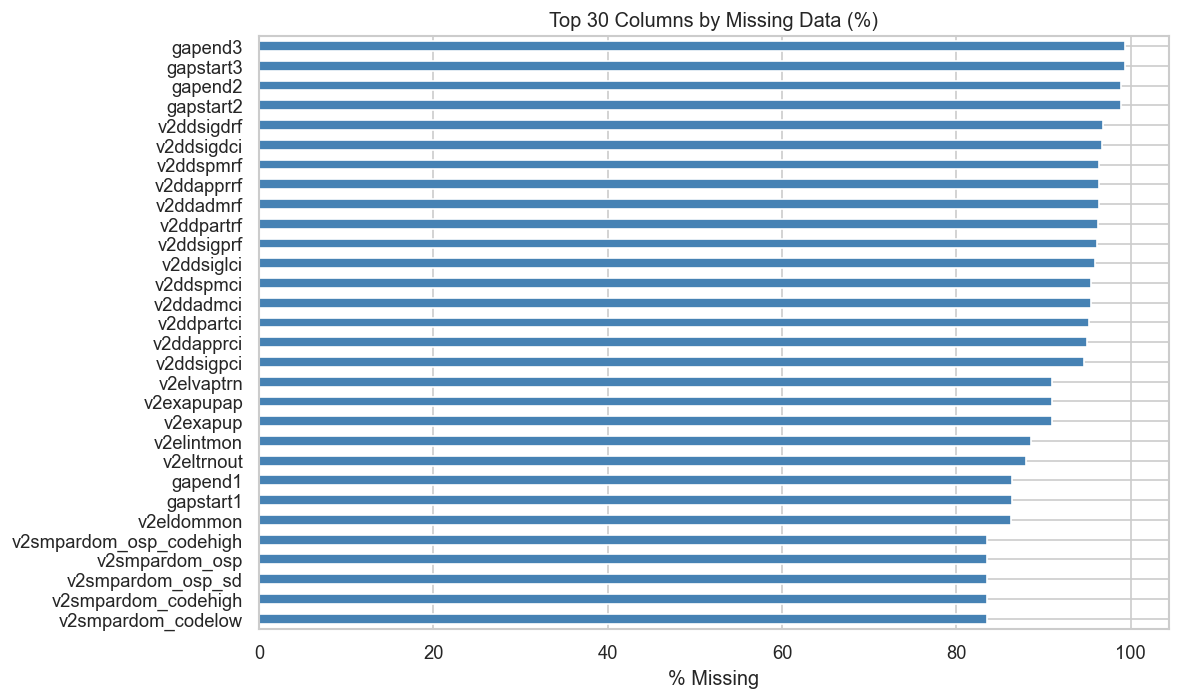

In [5]:
missing_pct = (df.isnull().mean() * 100).sort_values(ascending=False)

# Bucket columns by missingness
buckets = {
    "0%": (missing_pct == 0).sum(),
    "1–25%": ((missing_pct > 0) & (missing_pct <= 25)).sum(),
    "26–50%": ((missing_pct > 25) & (missing_pct <= 50)).sum(),
    "51–75%": ((missing_pct > 50) & (missing_pct <= 75)).sum(),
    ">75%": (missing_pct > 75).sum(),
}
print("Columns by missingness level:")
for k, v in buckets.items():
    print(f"  {k:>6}: {v:>4} columns")

# Plot top-30 columns with highest missingness
top_missing = missing_pct[missing_pct > 0].head(30)
fig, ax = plt.subplots(figsize=(10, 6))
top_missing.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("% Missing")
ax.set_title("Top 30 Columns by Missing Data (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

##### Observations
- **Column usability varies widely**
  - Total columns: **1,908**
  - Only **16 columns** have zero missing data  
  - **1,027 columns** have 1–25% missing &rarr; generally usable  
  - **165 columns** are >50% missing  
  - **79 columns** are >75% missing &rarr; largely unusable  

- **Highly sparse variables**
  - “Gap” variables (democratic interruptions) &rarr; ~95–100% missing  
  - “v2dd” variables (direct democracy) &rarr; ~95–100% missing  
  - This maybe due to historically absent or not systematically recorded  

- **Implications for your project**
  - **v2xca_academ (academic freedom)** likely in 1–25% missing range  
  - Reliable for modern periods; minor gaps in earlier centuries  
  - Case studies (e.g., specific countries/time windows) unlikely to face major missing data issues  

- **Ignore irrelevant sparsity**
  - Gap and v2dd variables are not relevant to your analysis  
  - Their missingness should not affect perceived dataset quality  

- **Moving forward**
  - Focusing only on variables required  
  - Avoid loading all 1,908 columns unnecessarily for cleaner, faster, and more interpretable EDA  

In [6]:
cols = [
    # identifiers
    'country_name',
    'country_id', 
    'year',
    
    # primary variable
    'v2xca_academ', # academic freedom index
    
    # democracy indices (for context/comparison)
    'v2x_polyarchy', # electoral democracy
    'v2x_libdem', # liberal democracy
    'v2x_partipdem', # participatory democracy
    'v2x_delibdem', # deliberative democracy
    'v2x_egaldem', # egalitarian democracy
    
    # regime type (useful for labelling your six cases)
    'v2x_regime', # 0=closed autocracy, 1=electoral autocracy, 2=electoral democracy, 3=liberal democracy
]

df = df[cols]

# filter to the six countries focused for this case study
countries = ['Germany', 'Russia', 'Chile', 'China', 'Hungary', 'United States of America']
df_cases = df[df['country_name'].isin(countries)]

print(df_cases['country_name'].unique())  # verify spellings matched

<StringArray>
['Russia', 'United States of America', 'Chile', 'Germany', 'China', 'Hungary']
Length: 6, dtype: str


#### Regime Type Distribution

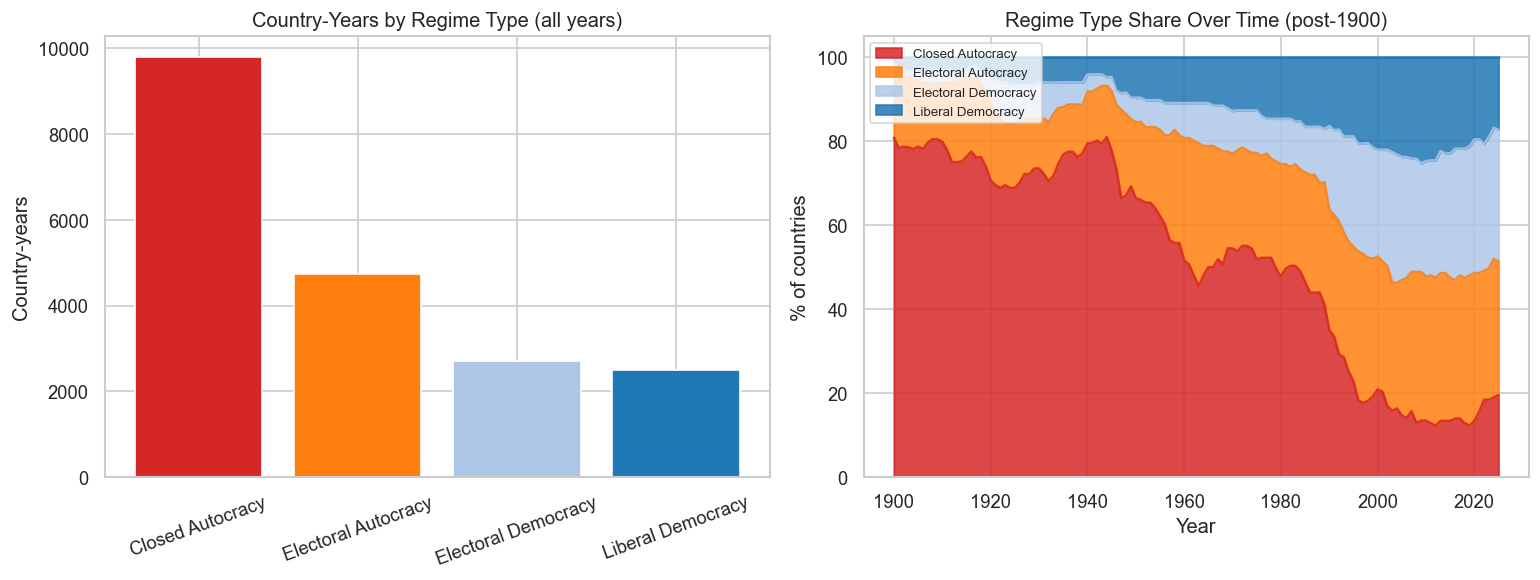

In [ ]:
regime_labels = {
    0: "Closed Autocracy",
    1: "Electoral Autocracy",
    2: "Electoral Democracy",
    3: "Liberal Democracy",
}
regime_colors = {
    "Closed Autocracy": "#d62728",
    "Electoral Autocracy": "#ff7f0e",
    "Electoral Democracy": "#aec7e8",
    "Liberal Democracy": "#1f77b4",
}

df["regime_label"] = df["v2x_regime"].map(regime_labels)

# — overall count —
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

counts = df["regime_label"].value_counts().reindex(regime_labels.values())
axes[0].bar(counts.index, counts.values,
            color=[regime_colors[r] for r in counts.index])
axes[0].set_title("Country-Years by Regime Type (all years)")
axes[0].set_ylabel("Country-years")
axes[0].tick_params(axis="x", rotation=20)

# — regime share over time (post-1900) —
modern = df[df["year"] >= 1900].copy()
regime_time = (modern.groupby(["year", "regime_label"])
               .size().unstack(fill_value=0))
regime_time_pct = regime_time.div(regime_time.sum(axis=1), axis=0) * 100
regime_time_pct[list(regime_labels.values())].plot.area(
    ax=axes[1],
    color=[regime_colors[r] for r in regime_labels.values()],
    alpha=0.85
)
axes[1].set_title("Regime Type Share Over Time (post-1900)")
axes[1].set_ylabel("% of countries")
axes[1].set_xlabel("Year")
axes[1].legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

##### Observations
- **Bar chart (overall distribution)**
  - **Closed autocracy dominates** (~10,000 country-years)  
  - **Liberal democracy is least common**  
  - Reinforces core idea where repression and control are historically typical, not exceptional  

- **Area chart (temporal trends)**
  - Reveals **three major eras** aligned with the proposed narrative  

  - **Pre-1945: Autocratic world**
    - Political systems overwhelmingly autocratic  
    - Context for cases like Germany and the USSR  

  - **1945–1990: Democratic expansion**
    - Decline of closed autocracy  
    - Rise of electoral autocracy and democracy  
    - Includes cases like Chile and its reversal under Pinochet  

  - **~2010–present: Democratic backsliding**
    - Growth of electoral autocracy (orange rising vs blue)  
    - Signals erosion of democratic norms  
    - Relevant to Hungary and emerging concerns in the US  

- **Narrative takeaway**
  - Historical pattern shows cycles, not linear progress  
  - Strengthens argument: control over knowledge persists across regime shifts  

### Democracy Indices - Distribution & Trends

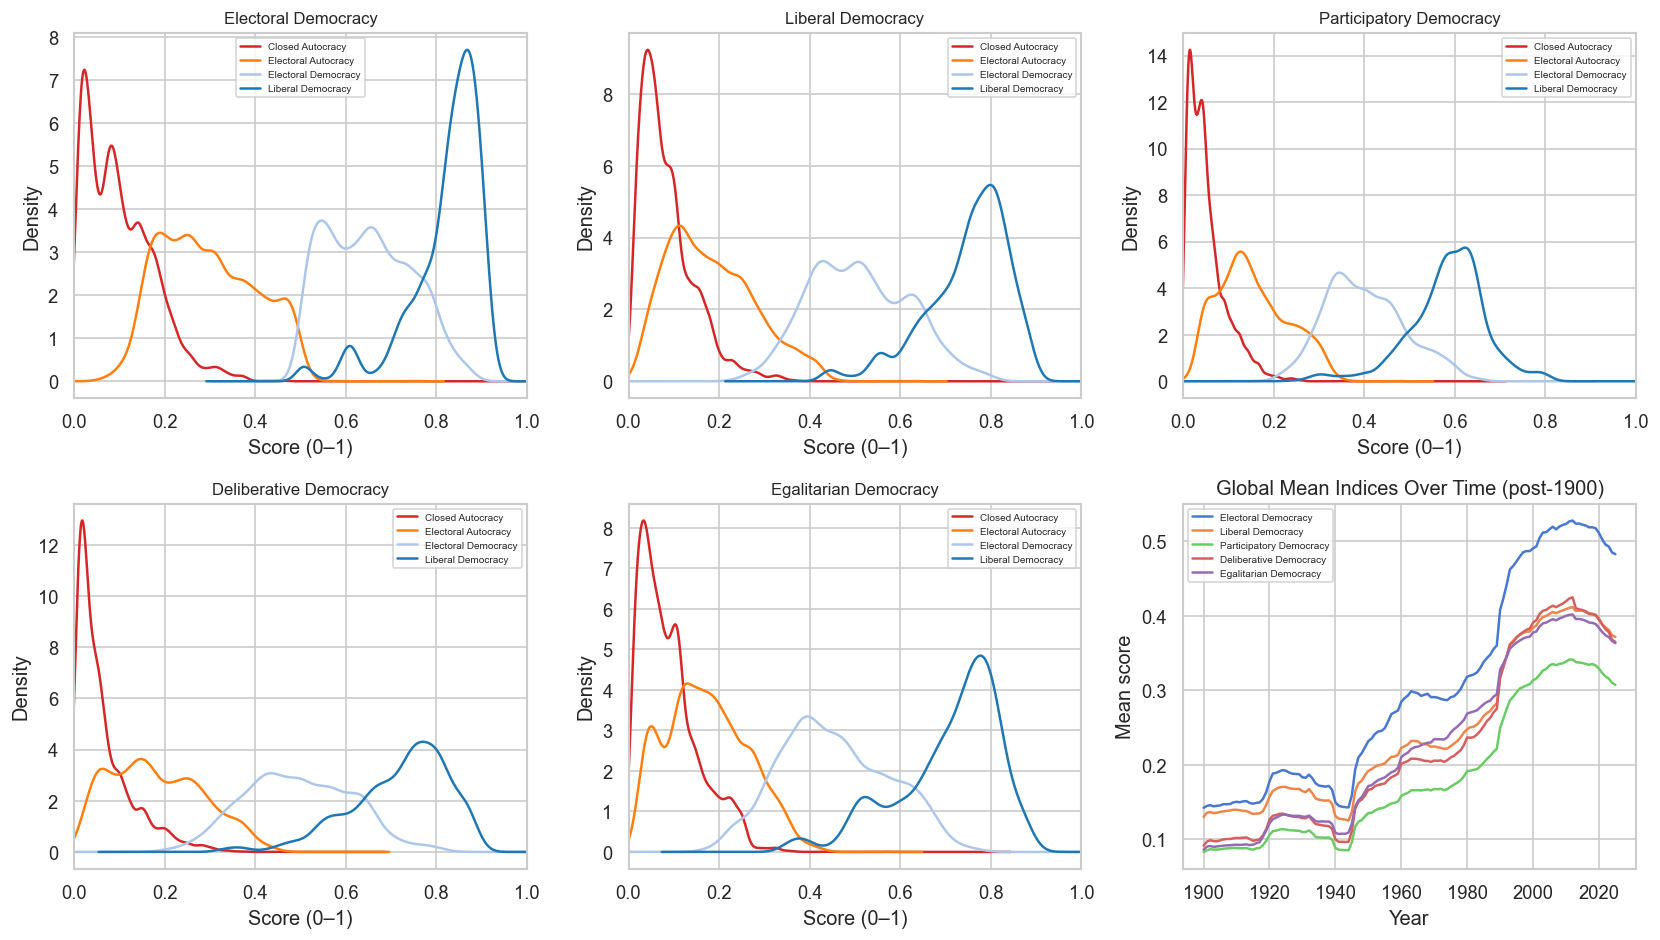

In [ ]:
index_labels = {
    "v2x_polyarchy": "Electoral Democracy",
    "v2x_libdem": "Liberal Democracy",
    "v2x_partipdem": "Participatory Democracy",
    "v2x_delibdem": "Deliberative Democracy",
    "v2x_egaldem": "Egalitarian Democracy",
}

# distributions (KDE) by regime 
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (col, label) in enumerate(index_labels.items()):
    ax = axes[i]
    for rname, rcolor in regime_colors.items():
        subset = df[df["regime_label"] == rname][col].dropna()
        subset.plot.kde(ax=ax, label=rname, color=rcolor, linewidth=1.5)
    ax.set_title(label, fontsize=10)
    ax.set_xlabel("Score (0–1)")
    ax.set_xlim(0, 1)
    ax.legend(fontsize=6)

# global mean over time 
ax = axes[5]
mean_over_time = df[df["year"] >= 1900].groupby("year")[list(index_labels.keys())].mean()
for col, label in index_labels.items():
    ax.plot(mean_over_time.index, mean_over_time[col], label=label, linewidth=1.5)
ax.set_title("Global Mean Indices Over Time (post-1900)")
ax.set_xlabel("Year")
ax.set_ylabel("Mean score")
ax.legend(fontsize=6)

plt.tight_layout()
plt.show()

##### Observations
- **KDE plots (density distributions)**
  - Clear separation between **closed autocracy (red)** and **liberal democracy (blue)**  
  - Minimal overlap across indices &rarr; regime type is a **strong predictor** of democratic freedoms  
  - Transitions into closed autocracy result in **near-total collapse** of scores  
  - Indicates suppression is **systematic, not marginal**  

- **Electoral autocracy (orange curve)**
  - Broad, flat distribution across **0.0–0.4 range**  
  - Represents regimes with **democratic form but weak substance**  
  - Ambiguity makes democratic erosion **difficult to detect in real time**  
  - Includes contemporary cases such as Hungary and trends observed in the United States  

- **Line chart (temporal trend)**
  - All indices **peak around 2010–2012**  
  - Followed by a **consistent decline across all dimensions**  
  - Reflects a **sustained global democratic reversal**, not a short-term fluctuation  

- **Narrative significance**
  - Establishes a **global baseline** for comparison  
  - National-level declines (e.g., Hungary post-2010) align with a **broader global pattern**  
  - Reinforces the interpretation of democratic backsliding as a **systemic, multi-dimensional trend**  

### Top & Bottom Countries - 2025


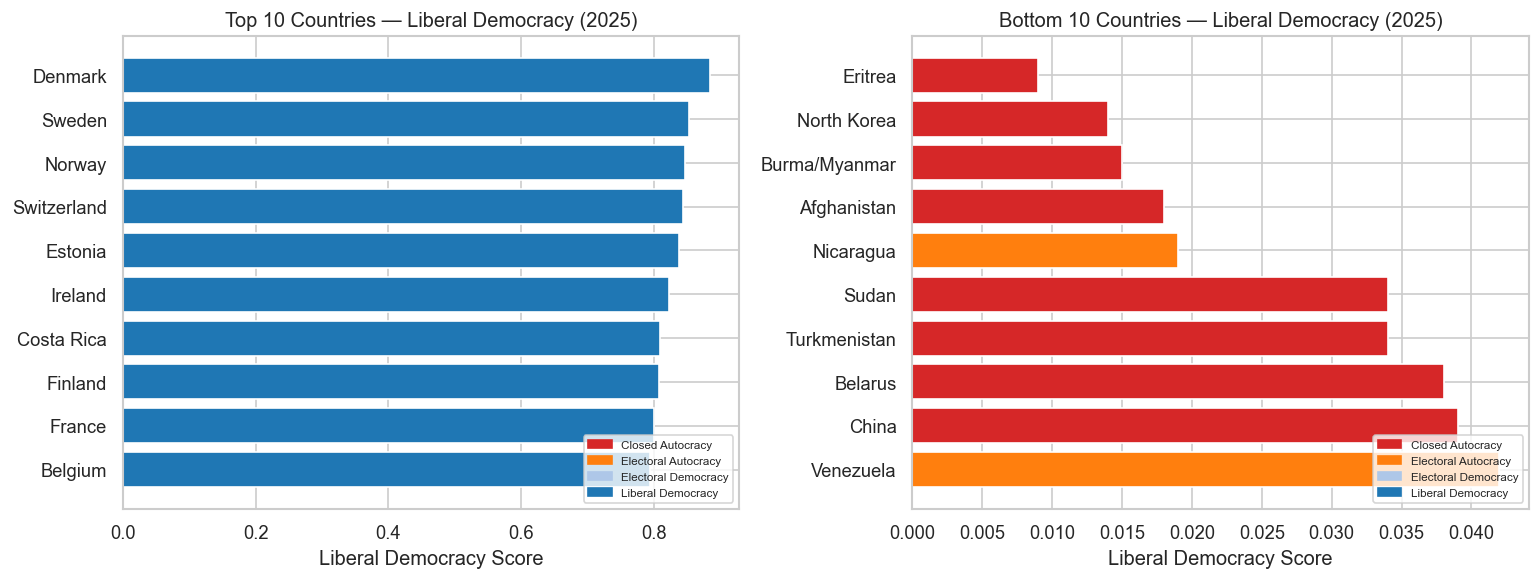

In [9]:
latest_year = df["year"].max()
latest = df[df["year"] == latest_year][["country_name", "v2x_polyarchy", "v2x_libdem", "regime_label"]].dropna()

focus = "v2x_libdem"
top10 = latest.nlargest(10, focus)
bot10 = latest.nsmallest(10, focus)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

def bar_countries(ax, data, title):
    colors = [regime_colors.get(r, "grey") for r in data["regime_label"]]
    ax.barh(data["country_name"], data[focus], color=colors)
    ax.set_xlabel("Liberal Democracy Score")
    ax.set_title(title)
    ax.invert_yaxis()
    # legend patches
    from matplotlib.patches import Patch
    handles = [Patch(color=c, label=l) for l, c in regime_colors.items()]
    ax.legend(handles=handles, fontsize=7, loc="lower right")

bar_countries(axes[0], top10, f"Top 10 Countries — Liberal Democracy ({latest_year})")
bar_countries(axes[1], bot10, f"Bottom 10 Countries — Liberal Democracy ({latest_year})")

plt.tight_layout()
plt.show()

##### Observations
- **Scale contrast is extreme**
  - Top countries score **~0.8–0.9** on the liberal democracy index  
  - Bottom countries score **~0.005–0.04**  
  - This reflects a **structural divide, not a gradient**  
  - Example: Denmark ≈ **0.88–0.9** vs Eritrea ≈ **0.01** :contentReference[oaicite:0]{index=0}  

- **Interpretation of the gap**
  - Lowest-ranked regimes are not “less democratic”  
  - They operate in a **qualitatively different political system**  
  - Democratic institutions (rights, checks, freedoms) are effectively absent  

- **Case country positioning**
  - China appears among the **lowest-ranked regimes in 2025**  
  - Positioned alongside highly repressive states such as North Korea and Eritrea  
  - Provides a **clear contemporary anchor** for analysis  

- **Electoral autocracy nuance**
  - Countries like Nicaragua and Venezuela fall into **electoral autocracy**, not closed autocracy  
  - Elections still occur, preventing classification as fully closed regimes  
  - However, liberal democracy scores remain **near the floor**  

- **Substantive takeaway**
  - Electoral autocracy functions as a **procedural façade**  
  - Minimal distinction in practice from closed autocracy in terms of freedoms  
  - Reinforces earlier finding: formal democratic structures do not guarantee democratic outcomes  

### Global Rank for the Six Case Countries

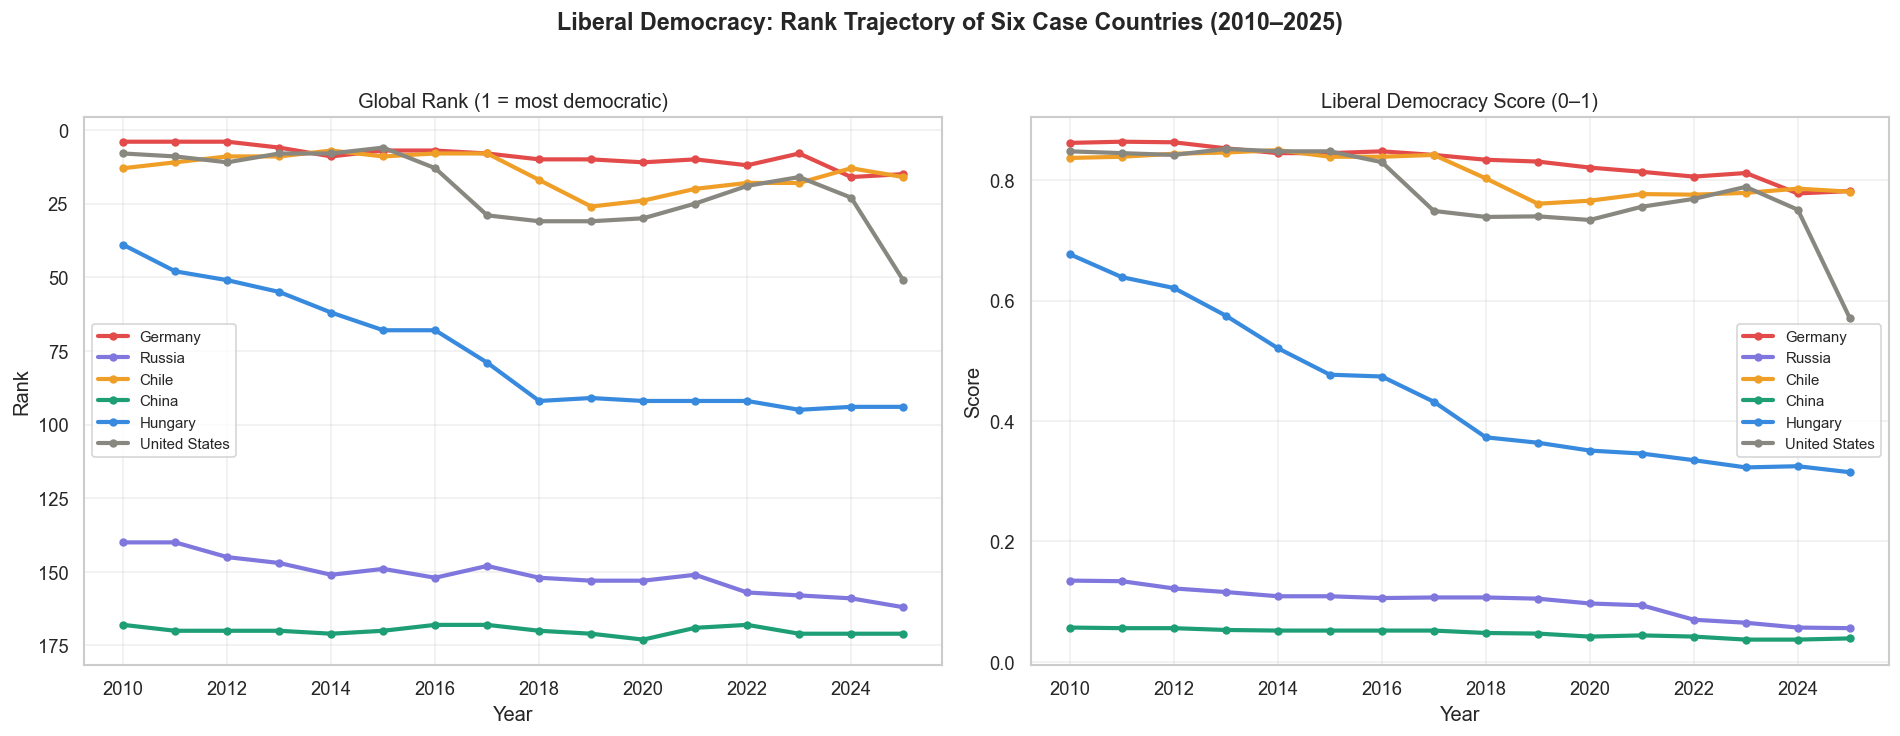


Rank Summary: 2010 vs 2025
-------------------------------------------------------
Germany                      4 →   15  (down 11 places)  score: 0.862 → 0.782
Russia                     140 →  162  (down 22 places)  score: 0.135 → 0.056
Chile                       13 →   16  (down 3 places)  score: 0.837 → 0.781
China                      168 →  171  (down 3 places)  score: 0.057 → 0.039
Hungary                     39 →   94  (down 55 places)  score: 0.677 → 0.315
United States                8 →   51  (down 43 places)  score: 0.848 → 0.571


In [11]:
countries = ['Germany', 'Russia', 'Chile', 'China', 'Hungary', 'United States of America']
colors = {
    'Germany': '#E24B4A',
    'Russia': '#7F77DD',
    'Chile': '#EF9F27',
    'China': '#1D9E75',
    'Hungary': '#378ADD',
    'United States of America': '#888780'
}
labels = {
    'United States of America': 'United States'
}

# compute global rank per year on liberal democracy (ascending = worst rank 1)
df['rank'] = df.groupby('year')['v2x_libdem'] \
               .rank(ascending=False, method='min')
total_countries = df.groupby('year')['country_name'].count()

# filter to your six cases, post-2010
case_ranks = df[
    (df['country_name'].isin(countries)) &
    (df['year'] >= 2010)
][['country_name', 'year', 'rank', 'v2x_libdem']].copy()

# merge total country count per year to compute percentile
case_ranks = case_ranks.merge(total_countries.rename('total'), on='year')
case_ranks['percentile_rank'] = (case_ranks['rank'] / case_ranks['total']) * 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Liberal Democracy: Rank Trajectory of Six Case Countries (2010–2025)',
             fontsize=14, fontweight='bold', y=1.02)

# left: raw rank (lower = better)
for country in countries:
    subset = case_ranks[case_ranks['country_name'] == country]
    label = labels.get(country, country)
    ax1.plot(subset['year'], subset['rank'],
             color=colors[country], linewidth=2.5, marker='o',
             markersize=4, label=label)

ax1.set_title('Global Rank (1 = most democratic)', fontsize=12)
ax1.set_xlabel('Year')
ax1.set_ylabel('Rank')
ax1.invert_yaxis()  # rank 1 at top
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

# right: actual score over time
for country in countries:
    subset = case_ranks[case_ranks['country_name'] == country]
    label = labels.get(country, country)
    ax2.plot(subset['year'], subset['v2x_libdem'],
             color=colors[country], linewidth=2.5, marker='o',
             markersize=4, label=label)

ax2.set_title('Liberal Democracy Score (0–1)', fontsize=12)
ax2.set_xlabel('Year')
ax2.set_ylabel('Score')
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('rank_trajectory_2010_2025.png', dpi=150, bbox_inches='tight')
plt.show()

# print a summary table
print("\nRank Summary: 2010 vs 2025")
print("-" * 55)
for country in countries:
    subset = case_ranks[case_ranks['country_name'] == country]
    if subset.empty:
        continue
    r2010 = subset[subset['year'] == 2010]['rank'].values
    r2025 = subset[subset['year'] == 2025]['rank'].values
    s2010 = subset[subset['year'] == 2010]['v2x_libdem'].values
    s2025 = subset[subset['year'] == 2025]['v2x_libdem'].values
    if len(r2010) and len(r2025):
        change = int(r2025[0]) - int(r2010[0])
        direction = 'down' if change > 0 else 'up'
        label = labels.get(country, country)
        print(f"{label:<25} {int(r2010[0]):>4} → {int(r2025[0]):>4}  ({direction} {abs(change)} places)  score: {s2010[0]:.3f} → {s2025[0]:.3f}")

### Correlation Matrix of Democracy Indices

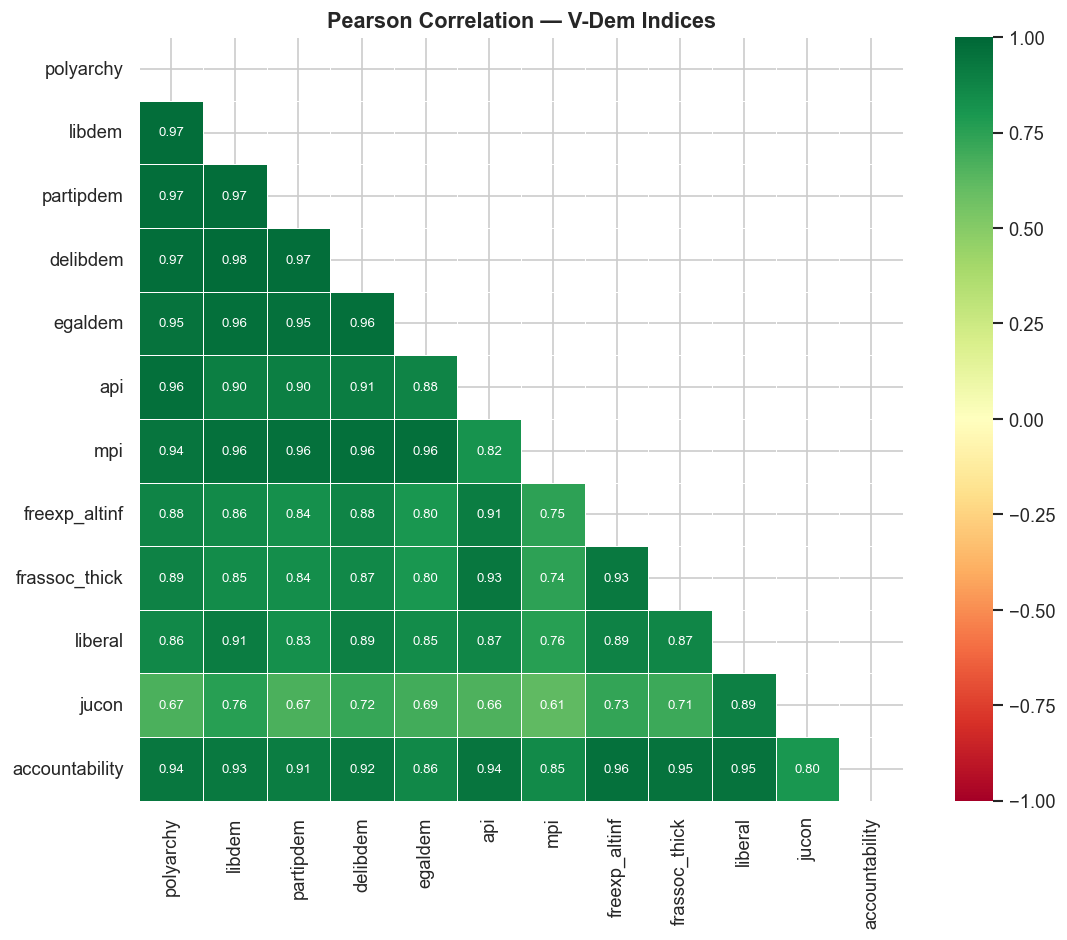

In [17]:
# loading extra columns from the original file
extra_cols = [
    'country_name', 'year',
    'v2x_api', 'v2x_mpi', 'v2x_freexp_altinf',
    'v2x_frassoc_thick', 'v2x_liberal', 'v2x_jucon',
    'v2x_accountability'
]

df_extra = pd.read_csv('data/V-Dem-CY-Core-v16.csv', usecols=extra_cols)

# merge with existing cut-down df (left join to keep rows intact) 
df_corr = df.merge(df_extra, on=['country_name', 'year'], how='left')

# define indices — only what now exists in df_corr
extended_indices = [
    'v2x_polyarchy', 'v2x_libdem', 'v2x_partipdem', 'v2x_delibdem', 'v2x_egaldem',
    'v2x_api', 'v2x_mpi', 'v2x_freexp_altinf', 'v2x_frassoc_thick',
    'v2x_liberal', 'v2x_jucon', 'v2x_accountability'
]

# safety check — drops any that still didn't load
available_indices = [c for c in extended_indices if c in df_corr.columns]
missing = [c for c in extended_indices if c not in df_corr.columns]
if missing:
    print(f"Still missing, dropped from heatmap: {missing}")

# compute correlation 
extended_labels = [c.replace('v2x_', '') for c in available_indices]

corr = df_corr[available_indices].corr()
corr.index = extended_labels
corr.columns = extended_labels

# plot
fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
    ax=ax, annot_kws={'size': 8}
)
ax.set_title('Pearson Correlation — V-Dem Indices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('vdem_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

##### Observations
- **High correlation across all indices**
  - Correlations range from **0.61 to 0.98**  
  - No negative or weak relationships  
  - All indices move **strongly together**  
  - Decline in one dimension (e.g., electoral democracy) is matched by declines across others  

- **Interpretation**
  - Democratic dimensions are **interdependent, not independent variables**  
  - Erosion occurs as a **system-wide process**, not in isolated areas  
  - Drops in democracy coincide with declines in:
    - Freedom of expression (~0.88+)  
    - Freedom of association (~0.89+)  
    - Judicial independence (~0.67+)  

- **Core implication**
  - Suppression of academic freedom is part of a **broader coordinated erosion**  
  - Restrictions on knowledge production align with wider institutional decline  
  - Supports the idea that control mechanisms operate **holistically across systems**  

- **Notable exception**
  - **Judicial constraints (jucon)** show weaker correlations (**0.61–0.76**)  
  - Judiciary tends to be **more resilient or slower to decline**  
  - Suggests a **sequencing effect**:
    - Media, academic, and associational freedoms weaken first  
    - Judicial institutions erode later  

- **Analytical takeaway**
  - Democratic backsliding is **multi-dimensional and synchronized**  
  - Institutional collapse follows identifiable patterns rather than random variation  

### Democratic Backsliding — Change in Polyarchy Score (2010-2025)

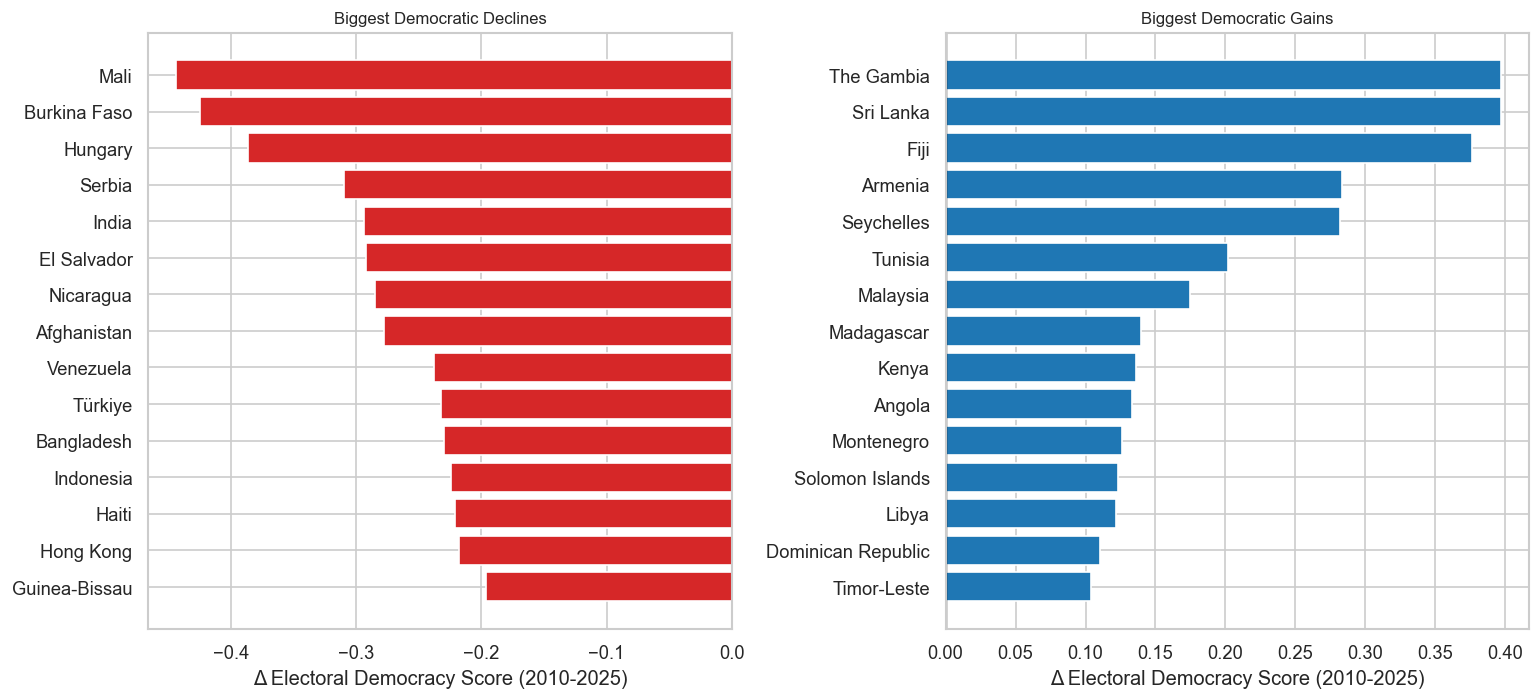

In [20]:
base_year = 2010
score_col = "v2x_polyarchy"

base = df[df["year"] == base_year][["country_name", score_col]].rename(columns={score_col: "score_2010"})
curr = df[df["year"] == latest_year][["country_name", score_col]].rename(columns={score_col: "score_latest"})
change = base.merge(curr, on="country_name").dropna()
change["delta"] = change["score_latest"] - change["score_2010"]

biggest_decline  = change.nsmallest(15, "delta")
biggest_increase = change.nlargest(15, "delta")

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

def delta_bar(ax, data, title):
    colors = ["#d62728" if d < 0 else "#1f77b4" for d in data["delta"]]
    ax.barh(data["country_name"], data["delta"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"Δ Electoral Democracy Score ({base_year}-{latest_year})")
    ax.set_title(title, fontsize=10)
    ax.invert_yaxis()

delta_bar(axes[0], biggest_decline,  "Biggest Democratic Declines")
delta_bar(axes[1], biggest_increase, "Biggest Democratic Gains")

plt.tight_layout()
plt.show()

##### Observations
- **Hungary as a top global decliner**
  - Ranked among the **largest democratic declines since 2010**  
  - Comparable to countries like Mali and Burkina Faso (military coups)  
  - Distinction: decline occurred through **legal and electoral mechanisms**, not force  
  - Widely identified as a **leading case of rapid autocratisation** :contentReference[oaicite:0]{index=0}  

- **Key contrast**
  - Mali & Burkina Faso → **sudden collapse via coups**  
  - Hungary → **gradual institutional capture** (laws, media, courts, universities)  
  - Outcome converges despite different pathways  

- **Other notable decliners**
  - **India** → large-scale democratic erosion in a major democracy  
  - **Turkey, Hong Kong, Nicaragua, Venezuela** → similar trajectory:
    - Centralisation of executive power  
    - Weakening of checks and balances  
    - Targeting of media, judiciary, and education systems  

- **United States: a differentiated pattern**
  - Absent from top electoral democracy decliners  
  - Indicates **slower erosion of electoral mechanisms**  
  - However, significant decline in **liberal dimensions** (rights, rule of law)  

- **Democratic “gainers” pattern**
  - Gains concentrated in:
    - Smaller states  
    - Previously authoritarian regimes  
    - Low baseline starting points  
  - No evidence of improvement among **established democracies**  

- **Overall interpretation**
  - Democratic gains appear **fragile and incremental**  
  - Democratic declines are **structural and large-scale**  
  - Hungary exemplifies a **global pattern**, not an isolated anomaly  